https://github.com/imperial-qore/line-solver/wiki/Getting-started#example-8-optimizing-a-performance-metric

In [1]:
from line_solver import *
from scipy import optimize
import numpy as np
GlobalConstants.setVerbose(VerboseLevel.STD)

In [2]:
def objFun(p):
    model = Network('LoadBalCQN')
    # Block 1: nodes
    delay = Delay(model, 'Think')
    queue1 = Queue(model, 'Queue1', SchedStrategy.PS)
    queue2 = Queue(model, 'Queue2', SchedStrategy.PS)
    # Block 2: classes
    cclass = ClosedClass(model, 'Job1', 16, delay)
    delay.setService(cclass, Exp(1))
    queue1.setService(cclass, Exp(0.75))
    queue2.setService(cclass, Exp(0.50))
    P = model.initRoutingMatrix()
    P.set(cclass, cclass, queue1, delay, 1.0)
    P.set(cclass, cclass, queue2, delay, 1.0)
    P.set(cclass, cclass, delay, queue1, p)
    P.set(cclass, cclass, delay, queue2, 1.0 - p)
    model.link(P)
    R = SolverMVA(model, 'exact', 'verbose', False).getAvgSysRespT()
    return R

In [3]:
p_opt = optimize.fminbound(objFun, 0, 1)
print(p_opt[0])

[19.77539155]
[13.65718723]
[16.29872417]
[13.63823499]
[13.67557454]
[13.63724724]
[13.63540131]
[13.63540133]
[13.63540131]
0.6093385580995628


[31.67242524]
[31.35233814]
[31.03225386]
[30.71217262]
[30.39209468]
[30.07202024]
[29.75194963]
[29.43188314]
[29.11183043]
[28.7917749]
[28.47172589]
[28.15168135]
[27.83164424]
[27.51161443]
[27.19159262]
[26.87157958]
[26.55157621]
[26.23158346]
[25.91160243]
[25.59163436]
[25.27168064]
[24.95174285]
[24.63182409]
[24.31192422]
[23.99206646]
[23.67221783]
[23.35239797]
[23.0326106]
[22.71286003]
[22.39315128]
[22.07349901]
[21.75388647]
[21.43436885]
[21.11490475]
[20.79552638]
[20.47624806]
[20.15708714]
[19.83809195]
[19.51924153]
[19.20059816]
[18.88218651]
[18.56411657]
[18.24636387]
[17.92910793]
[17.61239109]
[17.29639289]
[16.98133938]
[16.667495]
[16.3552608]
[16.04520672]
[15.73810321]
[15.43507375]
[15.13798489]
[14.84946051]
[14.57351963]
[14.31611712]
[14.08565017]
[13.89272523]
[13.74858532]
[13.66171447]
[13.63553106]
[13.66783652]
[13.75080664]
[13.87310622]
[14.02361573]
[14.19349748]
[14.37626746]
[14.56779376]
[14.76522463]
[14.96677898]
[15.17117921]
[15.3777388

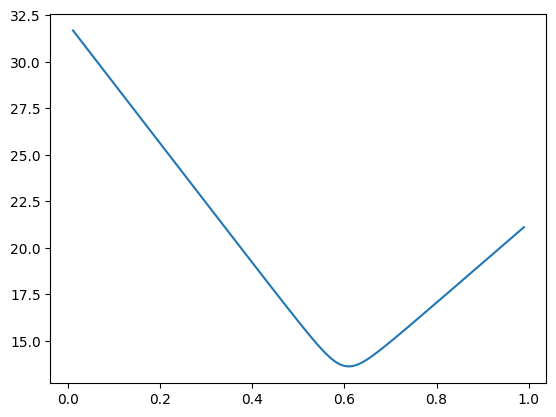

In [4]:
import matplotlib.pyplot as plt
y = []
x = np.arange(0.01,1,0.01)
y = np.array(list(map(lambda x:objFun(x), x)))
plt.plot(x, y);